# Baseline Model Runs: Triplet Loss

This notebook contains the code used to train a Vision Transformer model using triplet margin loss. Key visualizations to analyze the model's outputs are also included.

In [1]:
#Importing packages
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError
import os

#library functions
import helper_code.dataloading as dataloading
import helper_code.data_vis as data_vis
import helper_code.model_functions as model_functions
import helper_code.loss_functions as loss_functions
import helper_code.models as models
from helper_code.seeds import set_seed



d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We set the seed for reproducibility, though results still vary slightly

In [2]:
g = set_seed()

## Data Loading

First, we load the data that was imported from LabelStudio. The data is split into training, validation, and testing splits, then batched into dataloaders.

In [3]:
#Set directory to data and device for training
labels_csv = r"camera_data/coronado_hills_4pt.csv"
device = 'cuda'


load = True

#Set parameters for saving model
model_path = 'weights/'
model_name = "triplet_loss_model.pth"

#Load data and create dataloaders
data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize=True)
train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 2314/2314 [00:00<00:00, 6701.13it/s]


## Model Training

Next, we instantiate a Vision Transformer model and train it on the data we loaded.

In [4]:
#Create an encoder model and load weights from Quarter 1 project
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [5]:
loss_func = loss_functions.TripletMarginLoss(margin = 0.19)
optimizer = optim.Adam(encoder.parameters(), lr=1e-5) 
num_epochs = 10

Training the model

In [7]:
if load:
    encoder.load_state_dict(torch.load(os.path.join(model_path, model_name), map_location=device))
    losses = []
else:
    losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = 'triplet_loss_model.pth', 
                                path = 'weights/', device=device)

C:\Users\Aneesh\AppData\Local\Temp\ipykernel_22108\2331338332.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(os.path.join(model_path,

Saving the embeddings generated by this model

In [8]:
#Delete old collections of embeddings if they exist

client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass

#Save new collections of embeddings for training and validation data
dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, val_img_urls, val_a_ids = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [9]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=5)

In [10]:
#Saving embeddings to csv
pd.DataFrame(reduced_embeddings).to_csv("camera_data/reduced_embeddings_triplet.csv", index=False)
pd.DataFrame({"labels": train_labels, "img_urls": train_img_urls, "ids": train_a_ids}).to_csv("camera_data/labels_urls_ids_triplet.csv", index=False)

Text(0.5, 1.0, 'First two axes of embedding space generated by Triplet Loss model')

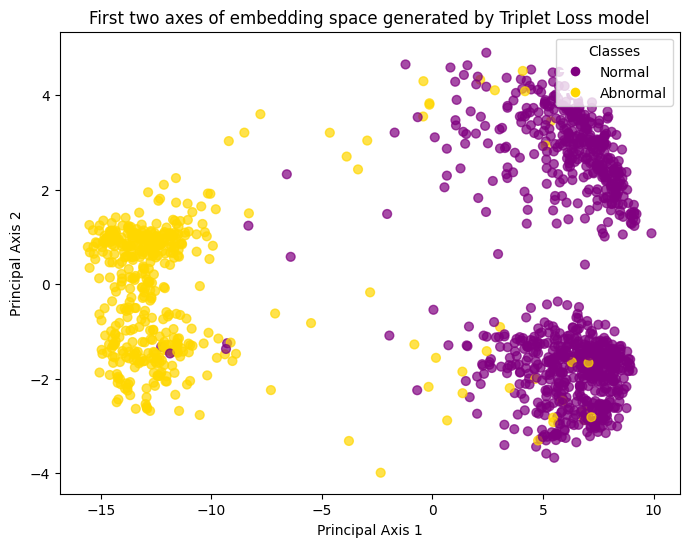

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space generated by Triplet Loss model")

Training classification head

In [13]:
losses = []

#Instantiate classification head
classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

#Define criterion and optimizer for training the classification head
head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=15, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name='triplet_loss_model_head.pth', model_path = "weights/", save=True)

classification_head.eval()

Processing batches in epoch 10:  32%|███▏      | 14/44 [00:01<00:02, 10.78it/s]


KeyboardInterrupt: 

Testing classification head outputs

In [28]:
#Function to calculate accuracy of classification head on given embeddings and labels
def get_accuracy(outputs, labels):
    return (torch.argmax(outputs, dim = -1) == labels).float().mean().item()

#Convert embeddings and labels to tensors for calculating accuracy
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)

#Obtain outputs from classification head and calculate accuracy
train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {get_accuracy(train_outputs, train_labels_tensor)}")
print(f"Validation accuracy: {get_accuracy(val_outputs, val_labels_tensor)}")

Training accuracy: 0.9762247800827026
Validation accuracy: 0.9330453276634216


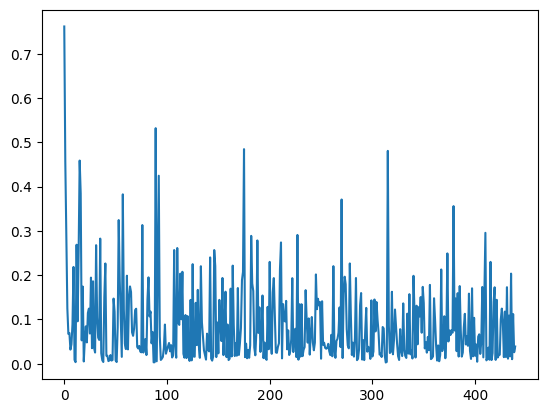

In [29]:
plt.plot(list(range(len(losses))), losses)

In [18]:
def get_val_embeddings(label_data, loc_name, model):    
    data = dataloading.get_data(label_data, 'camera_data/images/', replace_images = False, binarize=True)
    train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
    _, val_dataloader, _ = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

    client = PersistentClient(path="embedding_data/") 

    try:
        client.delete_collection(name=f"{loc_name}_val_embeddings")
    except Exception:
        pass

    dataloading.save_full_embeddings(model, val_dataloader, 
                        f"{loc_name}_val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    val_embeddings, val_labels, val_img_urls, val_a_ids = dataloading.load_full_embeddings(val, f"{loc_name}_val_embeddings", persist_directory = "embedding_data/")

    return val_embeddings, val_labels, val_img_urls, val_a_ids

100%|██████████| 2314/2314 [00:00<00:00, 7005.78it/s]


Validation accuracy for coronado_hills: 0.9632828831672668


100%|██████████| 1914/1914 [00:00<00:00, 2621.76it/s]


Validation accuracy for mesa_grande: 0.9660574793815613


100%|██████████| 2042/2042 [00:00<00:00, 6774.95it/s]


Validation accuracy for palomar: 0.9877750873565674


C:\Users\Aneesh\AppData\Local\Temp\ipykernel_37516\1856579907.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


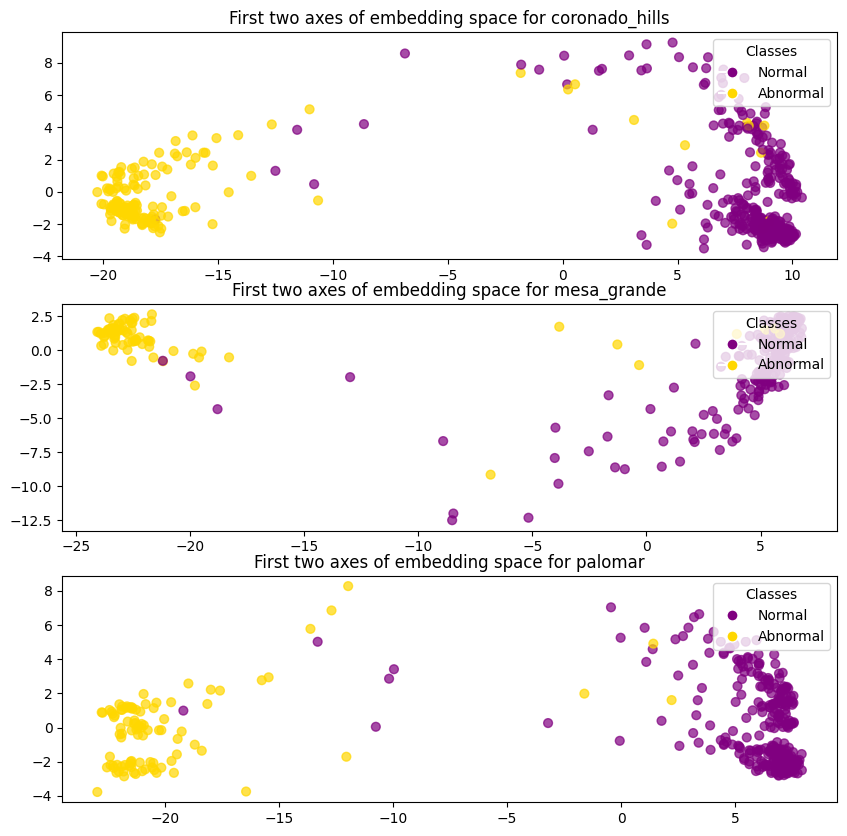

In [ ]:
coronado_fp = r"camera_data/images/coronado_hills_4pt.csv"
mesa_grande_fp = r"camera_data/images/mesa_grande_4pt.csv"
palomar_fp = r"camera_data/images/palomar_4pt.csv"

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
for i, location in enumerate(["coronado_hills", "mesa_grande", "palomar"]):
    val_embeddings, val_labels, val_img_urls, val_a_ids = get_val_embeddings(f"camera_data/{location}_4pt.csv", location, encoder)
    reduced_embeddings, labels = model_functions.reduce_pca(val_embeddings, val_labels, dimensions=5)
    
    ax[i] = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax[i])
    ax[i].set_title(f"First two axes of embedding space for {location}")

    pd.DataFrame(reduced_embeddings).to_csv(f"camera_data/reduced_embeddings_{location}.csv", index=False)
    pd.DataFrame({"labels": labels, "img_urls": val_img_urls, "ids": val_a_ids}).to_csv(f"camera_data/labels_urls_ids_{location}.csv", index=False)

    val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

    val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)

    val_outputs = classification_head(val_embeddings_tensor)

    print(f"Validation accuracy for {location}: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

fig.show() 

100%|██████████| 2314/2314 [00:00<00:00, 6518.89it/s]


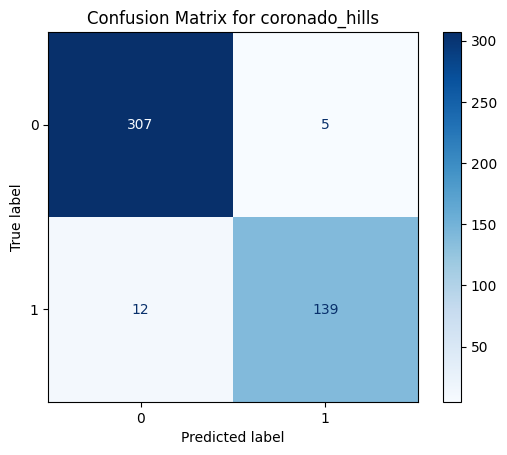

Recall: 0.9205
Precision: 0.9653


100%|██████████| 1914/1914 [00:00<00:00, 3057.99it/s]


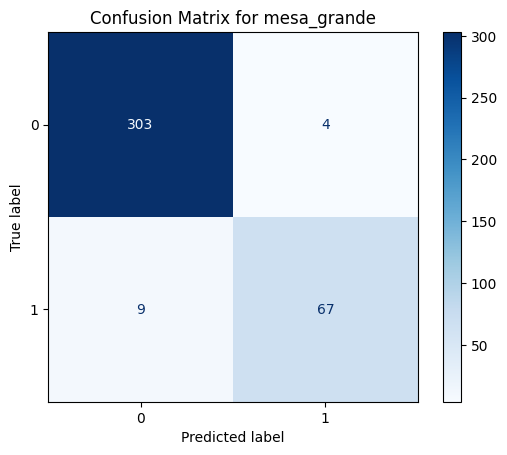

Recall: 0.8816
Precision: 0.9437


100%|██████████| 2042/2042 [00:00<00:00, 6645.41it/s]


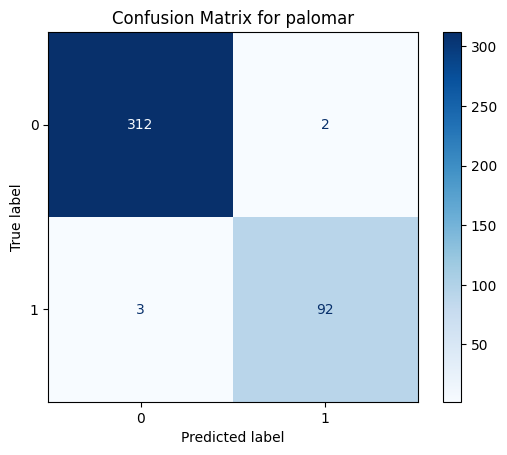

Recall: 0.9684
Precision: 0.9787


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

    recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    precision = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0
    print(f"Recall: {recall:.4f}")  
    print(f"Precision: {precision:.4f}")

for i, location in enumerate(["coronado_hills", "mesa_grande", "palomar"]):
    val_embeddings, val_labels, val_img_urls, val_a_ids = get_val_embeddings(f"camera_data/{location}_4pt.csv", location, encoder)
    val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)
    val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)
    val_outputs = classification_head(val_embeddings_tensor)
    pred_labels = torch.argmax(val_outputs, dim=-1).cpu().numpy()
    plot_confusion_matrix(val_labels_tensor.cpu().numpy(), pred_labels, title=f"Confusion Matrix for {location}")